# Search-12 — Bases de données de motifs (Pattern Databases) pour le 15-puzzle

> **Partie 3 — Recherche avancée.** Ce notebook ouvre la Partie 3 : techniques de
> recherche heuristique *avancées*, au-delà des fondations de la
> [Partie 1](../Part1-Foundations/Search-3-Informed.ipynb) (A\*, IDA\*, heuristiques
> admissibles), sans relever ni de la programmation par contraintes
> ([Partie 2](../Part2-CSP/CSP-1-Fundamentals.ipynb)) ni des métaheuristiques
> ([Partie 4](../Part4-Metaheuristics/README.md)).

## 1. Le problème, et pourquoi Manhattan ne suffit plus

Le **15-puzzle** (taquin 4×4) est le banc d'essai historique de la recherche
heuristique : 15 tuiles + 1 case vide, on glisse les tuiles vers la configuration
ordonnée. Résoudre *à l'optimum* est **NP-difficile** et constitue, depuis
**Korf (1985)**, la référence pour mesurer un solveur de recherche.

[Search-3](../Part1-Foundations/Search-3-Informed.ipynb) a introduit **IDA\***
et l'heuristique **Manhattan** (somme des distances individuelles des tuiles).
Manhattan est *admissible* (ne surestime jamais), donc IDA\* + Manhattan est
optimal. Mais elle ignore les **interactions** entre tuiles (deux tuiles qui se
bloquent coûtent plus que la somme de leurs distances) : sur les instances
difficiles de Korf (~50 coups optimaux), IDA\* + Manhattan explore des
**centaines de milliards** de nœuds.

La SOTA, depuis **Culberson & Schaeffer (1996)** puis **Korf & Felner (2002)**,
consiste à *précalculer* une heuristique admissible bien plus fine : la **base de
données de motifs**. Ce notebook construit d'abord une PDB simple (concept), puis
la **PDB additive** qui est, quarante ans après Korf, la référence absolue du
15-puzzle.

## 2. Formalisation du 15-puzzle

État = tuple de 16 entiers (cellules en row-major), `0` = case vide. But = tuiles
1..15 en ordre, vide en bas à droite.

In [1]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import time, random

GOAL = (1,2,3,4, 5,6,7,8, 9,10,11,12, 13,14,15,0)
N = 4

def neighbors(cell):
    r, c = divmod(cell, N)
    out = []
    if r > 0: out.append(cell - N)
    if r < N - 1: out.append(cell + N)
    if c > 0: out.append(cell - 1)
    if c < N - 1: out.append(cell + 1)
    return out

def move(state, blank, nxt):
    s = list(state); s[blank], s[nxt] = s[nxt], s[blank]; return tuple(s)

def successors(state):
    b = state.index(0)
    return [move(state, b, n) for n in neighbors(b)]

assert len(successors(GOAL)) == 2  # le coin bas-droit a 2 voisins
print("OK : le but a", len(successors(GOAL)), "successeurs")

OK : le but a 2 successeurs


## 3. Heuristique de Manhattan (référence, vu en Search-3)

In [2]:
GOAL_POS = {t: i for i, t in enumerate(GOAL)}

def manhattan(state):
    h = 0
    for cell, t in enumerate(state):
        if t == 0: continue
        gr, gc = divmod(GOAL_POS[t], N)
        cr, cc = divmod(cell, N)
        h += abs(gr - cr) + abs(gc - cc)
    return h

assert manhattan(GOAL) == 0
print("Manhattan(but) =", manhattan(GOAL))

Manhattan(but) = 0


### 3.b Mélange reproductible (marche aléatoire)

On brouille le but par une marche aléatoire longue (90-130 pas), ce qui produit
des instances *réalistement difficiles* (optimal typiquement ~38-46 coups) — bien
plus coût à résoudre que les instances jouets où Manhattan est instantané.

In [3]:
def scramble(goal, n_steps, seed=0):
    rng = random.Random(seed)
    s, prev = goal, None
    for _ in range(n_steps):
        b = s.index(0)
        cands = [n for n in neighbors(b) if move(s, b, n) != prev]
        nxt = rng.choice(cands)
        prev = s
        s = move(s, b, nxt)
    return s

INST = scramble(GOAL, 100, seed=11)
print("Instance de démo :", INST)
print("Manhattan =", manhattan(INST), "(borne inférieure ; l'optimal est nettement supérieur)")

Instance de démo : (7, 12, 11, 2, 10, 0, 4, 6, 9, 3, 5, 8, 13, 15, 1, 14)
Manhattan = 32 (borne inférieure ; l'optimal est nettement supérieur)


## 4. Concept : base de données de motifs

L'idée de Culberson & Schaeffer (1996) :

1. **Abstraction.** On choisit un *motif* (sous-ensemble de tuiles). Les autres
   deviennent des jokers indifférenciés (*wildcards*).
2. **Parcours rétrograde.** Dans l'espace abstrait, BFS *depuis le but abstrait*,
   enregistrant pour chaque état abstrait le **coût optimal** pour y ramener le motif.
3. **Consultation.** Pour un état concret, on l'abstrait et on lit le coût en O(1).

**Admissibilité.** L'espace abstrait *relâche* le problème (les jokers se
substituent gratuitement) → le coût abstrait minore le coût réel → heuristique
admissible. IDA\* + PDB reste donc optimal.

**Fonction de rang.** Pour stocker la table dans un tableau compact, on *range*
chaque état abstrait vers un entier : rang de permutation des positions du motif
`P(16,k)`, multiplié par le nombre de cellules restantes pour le vide.

In [4]:
from math import factorial
def P(n, k):
    r = 1
    for i in range(k): r *= (n - i)
    return r

def perm_rank(positions, base=16):
    '''Rang (Lehmer) d'un arrangement ordonné de |positions| valeurs distinctes < base.'''
    avail = list(range(base)); rank = 0; k = len(positions)
    for i, p in enumerate(positions):
        idx = avail.index(p)
        rank += idx * P(base - 1 - i, k - 1 - i)
        avail.pop(idx)
    return rank

def rank_abstract(pos, blank, k):
    '''Rang d'un état abstrait (k tuiles du motif + case vide) dans 16 cellules.'''
    r_perm = perm_rank(pos, 16)
    remaining = [c for c in range(16) if c not in pos]
    return r_perm * (16 - k) + remaining.index(blank)

# Test d'injectivité : deux états abstraits *distincts* ne doivent jamais
# partager le même rang (l'abstraction est many-to-one par construction, on teste
# donc l'injectivité du rang, pas l'absence de collisions de classes).
rng = random.Random(1)
seen = {}; collisions = 0
for _ in range(20000):
    chosen = rng.sample(range(16), 6)
    pos, blank = tuple(chosen[:5]), chosen[5]
    rk = rank_abstract(pos, blank, 5)
    if rk in seen:
        if seen[rk] != (pos, blank): collisions += 1
    else:
        seen[rk] = (pos, blank)
print(f"Injectivité du rang : {len(seen)} états abstraits testés, {collisions} collision (attendu 0)")
assert collisions == 0

Injectivité du rang : 19961 états abstraits testés, 0 collision (attendu 0)


## 5. PDB simple : construction par BFS rétrograde

On construit d'abord une PDB sur **un** motif de 4 tuiles. BFS = coût unitaire =
distances optimales depuis le but abstrait. Cette PDB unique couvre 4 tuiles ;
elle servira de briques, puis la **PDB additive** (section 7) en combinera
plusieurs pour couvrir les 15 tuiles.

In [5]:
def build_pdb(group):
    '''BFS rétrograde sur le groupe de tuiles. Coût unitaire = distance optimale.
    Renvoie (table uint8, n_états_atteignables).'''
    k = len(group); gset = set(group)
    goal_pos = tuple(GOAL.index(t) for t in group)
    goal_blank = GOAL.index(0)
    size = P(16, k) * (16 - k)
    table = np.full(size, 255, dtype=np.uint8)
    table[rank_abstract(goal_pos, goal_blank, k)] = 0
    q = deque([(goal_pos, goal_blank)]); n_seen = 1
    while q:
        pos, blank = q.popleft()
        d = table[rank_abstract(pos, blank, k)]
        pset = set(pos)
        for n in neighbors(blank):
            if n in pset:                                   # tuile du groupe bouge
                ti = pos.index(n)
                new_pos = pos[:ti] + (blank,) + pos[ti+1:]; new_blank = n
            else:                                            # joker : seul le vide bouge
                new_pos = pos; new_blank = n
            rk = rank_abstract(new_pos, new_blank, k)
            if table[rk] == 255:
                table[rk] = d + 1; q.append((new_pos, new_blank)); n_seen += 1
    return table, n_seen

def pdb_lookup(state, table, group):
    pos = tuple(state.index(t) for t in group)
    return int(table[rank_abstract(pos, state.index(0), len(group))])

PATTERN = (1, 2, 3, 4)   # motif de 4 tuiles (concept) ; la PDB additive ci-après en combine 4
t0 = time.time()
PDB5, n5 = build_pdb(PATTERN)
print(f"PDB simple ({len(PATTERN)} tuiles) : {n5:,} états en {time.time()-t0:.1f}s, "
      f"distance max = {int(PDB5[PDB5<255].max())}")

PDB simple (4 tuiles) : 524,160 états en 9.3s, distance max = 50


## 6. La SOTA : PDB *additives* (Korf & Felner 2002)

Une PDB unique sur 4 tuiles n'informe qu'environ un quart du puzzle. L'idée de génie de
Korf & Felner (2002) : **partitionner** les 15 tuiles en groupes *disjoints* et
construire une PDB par groupe, en ne comptant — dans chaque BFS — **que les
mouvements des tuiles du groupe**. Les coûts deviennent alors **additifs** :

$$h(s) = \sum_{\text{groupes } G} \mathrm{PDB}_G(s)$$

est une heuristique **admissible** : chaque coup du taquin déplace exactement une
tuile, donc la somme des minima par groupe disjoint minore le nombre total de
coups.

On utilise une partition **4-4-4-3** (les groupes couvrent les 15 tuiles). Le BFS
devient un **0-1 BFS** : déplacer une tuile du groupe coûte 1, déplacer la case
vide à travers un joker coûte 0.

In [6]:
GROUPS = [(1,2,3,4), (5,6,7,8), (9,10,11,12), (13,14,15)]  # partition 4-4-4-3

def build_additive_pdb(group):
    '''0-1 BFS : coût 1 si une tuile du groupe bouge, 0 sinon (joker).'''
    k = len(group)
    goal_pos = tuple(GOAL.index(t) for t in group)
    goal_blank = GOAL.index(0)
    size = P(16, k) * (16 - k)
    dist = np.full(size, 255, dtype=np.uint8)
    dist[rank_abstract(goal_pos, goal_blank, k)] = 0
    dq = deque([(goal_pos, goal_blank)]); n_seen = 1
    while dq:
        pos, blank = dq.popleft()
        d = dist[rank_abstract(pos, blank, k)]
        pset = set(pos)
        for n in neighbors(blank):
            if n in pset:                                    # tuile du groupe bouge -> coût 1
                ti = pos.index(n)
                new_pos = pos[:ti] + (blank,) + pos[ti+1:]; new_blank = n; w = 1
            else:                                            # joker -> coût 0
                new_pos = pos; new_blank = n; w = 0
            rk = rank_abstract(new_pos, new_blank, k)
            if dist[rk] == 255:
                dist[rk] = d + w
                (dq.appendleft if w == 0 else dq.append)((new_pos, new_blank))
                n_seen += 1
    return dist, n_seen

t0 = time.time()
ADDITIVE = [build_additive_pdb(g) for g in GROUPS]
ADD_TBLS = [t for t, _ in ADDITIVE]
print(f"PDB additives (4-4-4-3) construites en {time.time()-t0:.1f}s")
for g, (tbl, ns) in zip(GROUPS, ADDITIVE):
    print(f"  groupe {g}: {ns:,} états, dist max = {int(tbl[tbl<255].max())}")

PDB additives (4-4-4-3) construites en 28.2s
  groupe (1, 2, 3, 4): 524,160 états, dist max = 21
  groupe (5, 6, 7, 8): 524,160 états, dist max = 17
  groupe (9, 10, 11, 12): 524,160 états, dist max = 19
  groupe (13, 14, 15): 43,680 états, dist max = 16


## 7. IDA\* instrumenté

Rappel de [Search-3](../Part1-Foundations/Search-3-Informed.ipynb) : seuils
itératifs sur `f = g + h`, recherche en profondeur. On compte les **nœuds
explorés** (métrique du coût de recherche). On l'introduit avant l'heuristique
additive car il sert à sa vérification d'admissibilité ci-après.

In [7]:
def ida_star(start, heuristic, goal=GOAL, node_limit=20_000_000):
    threshold = heuristic(start); nodes = 0
    while True:
        res, t, n = _dfs(start, 0, threshold, heuristic, goal, {start}, node_limit - nodes)
        nodes += n
        if res is not None: return res, nodes
        if t == float('inf') or nodes >= node_limit: return None, nodes
        threshold = t

def _dfs(state, g, threshold, heuristic, goal, path, budget):
    f = g + heuristic(state)
    if f > threshold: return None, f, 0
    if state == goal: return g, f, 0
    if budget <= 0: return None, float('inf'), 0
    n_total = 1; next_t = float('inf'); b = state.index(0)
    for n in neighbors(b):
        s2 = move(state, b, n)
        if s2 in path: continue
        path.add(s2)
        res, t, nn = _dfs(s2, g+1, threshold, heuristic, goal, path, budget - n_total)
        n_total += nn; path.discard(s2)
        if res is not None: return res, t, n_total
        if t < next_t: next_t = t
        if n_total >= budget: return None, next_t, n_total
    return None, next_t, n_total

# Sanity préliminaire : Manhattan est admissible et résout une instance facile.
easy = scramble(GOAL, 8, seed=1)
sm, _ = ida_star(easy, manhattan)
print(f"Sanity : instance facile optimal={sm} (Manhattan résout bien)")

Sanity : instance facile optimal=8 (Manhattan résout bien)


## 8. Heuristique additive et vérification d'admissibilité

`h_additive(s) = Σ PDB_groupe(s)`. On **vérifie empiriquement l'admissibilité** :
sur un échantillon d'instances résolues à l'optimum (via Manhattan, elle-même
admissible), `h_additive(s) ≤ optimal(s)` doit toujours tenir. On vérifie aussi la
convergence (même optimum) sur une instance facile.

In [8]:
def h_additive(state):
    return sum(pdb_lookup(state, tbl, g) for tbl, g in zip(ADD_TBLS, GROUPS))

# Convergence : deux heuristiques admissibles -> même optimum.
sa, _ = ida_star(easy, h_additive)
assert sm == sa
print(f"Convergence confirmée : additive optimal={sa} == Manhattan optimal={sm}")

# Admissibilité empirique : h_additive <= optimal (optimal via Manhattan-IDA*).
rng = random.Random(7); checked = 0; violations = 0
for _ in range(40):
    s = scramble(GOAL, 14, seed=rng.randrange(10**9))   # instance facile -> optimal vite trouvé
    opt, _ = ida_star(s, manhattan)                      # défini ci-dessus (§7)
    if opt is None: continue
    if h_additive(s) > opt: violations += 1
    checked += 1
print(f"Admissibilité : {checked} instances, h_additive <= optimal tient {checked-violations}/{checked} fois")
assert violations == 0
print("OK : h_additive est admissible (ne surestime pas la vraie distance).")
# Dominance vs Manhattan sur une instance
print(f"Sur l'instance de démo : Manhattan={manhattan(INST)}, h_additive={h_additive(INST)} "
      f"(additive >= Manhattan attendu)")

Convergence confirmée : additive optimal=8 == Manhattan optimal=8
Admissibilité : 40 instances, h_additive <= optimal tient 40/40 fois
OK : h_additive est admissible (ne surestime pas la vraie distance).
Sur l'instance de démo : Manhattan=32, h_additive=36 (additive >= Manhattan attendu)


## 9. Expérience : Manhattan vs PDB additive (la valeur du moteur, visible)

Trois instances **réalistement difficiles** (brouillage 50-90 pas, optimal ~26-52
coups). On résout à l'optimum avec (a) Manhattan seule, puis (b) la PDB additive.
On mesure les **nœuds explorés** : c'est la métrique qui révèle la puissance de
l'heuristique. Sur les instances les plus dures, Manhattan frappe la limite
(20M nœuds) tandis que la PDB additive en explore **un ordre de grandeur moins**
et termine.

In [9]:
INSTANCES = {
    "I1 (brouillage 50)": scramble(GOAL, 50, seed=11),
    "I2 (brouillage 70)": scramble(GOAL, 70, seed=23),
    "I3 (brouillage 90)": scramble(GOAL, 90, seed=41),
}

rows = []
for name, s in INSTANCES.items():
    t0 = time.time(); sol_m, nm = ida_star(s, manhattan); tm = time.time() - t0
    t0 = time.time(); sol_a, na = ida_star(s, h_additive); ta = time.time() - t0
    opt = sol_m if sol_m is not None else sol_a
    speedup = (nm / na) if (nm and na and nm > 0) else float('nan')
    rows.append((name, opt, manhattan(s), h_additive(s), nm, na, speedup, tm, ta))
    nm_s = f"{nm:>12,}" if nm is not None else "  >= 20M (limite)"
    na_s = f"{na:>12,}" if na is not None else "  >= 20M (limite)"
    print(f"{name:20s} optimal={opt} | Manhattan: {nm_s} ({tm:6.1f}s) | "
          f"additive: {na_s} ({ta:6.1f}s) | speedup x{speedup:6.1f}")

bench = rows

I1 (brouillage 50)   optimal=26 | Manhattan:          653 (   0.0s) | additive:           78 (   0.0s) | speedup x   8.4


I2 (brouillage 70)   optimal=40 | Manhattan:      655,908 (   6.4s) | additive:       63,018 (   2.8s) | speedup x  10.4


I3 (brouillage 90)   optimal=52 | Manhattan:   20,000,000 ( 191.9s) | additive:      972,772 (  43.2s) | speedup x  20.6


### Lecture du résultat : pourquoi le speedup **croît** avec la difficulté

Le tableau ci-dessus raconte l'histoire la plus importante de ce notebook, et elle
n'est pas dans les chiffres absolus — elle est dans la **dernière colonne**.

| Instance | Optimal | Nœuds Manhattan | Nœuds PDB additive | Speedup |
|---|---|---|---|---|
| I1 (brouillage 50) | 26 | 653 | 78 | **× 8,4** |
| I2 (brouillage 70) | 40 | 655 908 | 63 018 | **× 10,4** |
| I3 (brouillage 90) | 52 | 20 000 000 *(limite)* | 972 772 | **× 20,6** |

Deux phénomènes, un seul mécanisme :

1. **Le speedup n'est pas constant, il augmente avec la difficulté.** Sur l'instance
   facile (I1), Manhattan explore 653 nœuds et la PDB additive 78 — l'écart existe
   mais les deux terminent en moins de 0,1 s, donc invisible en pratique. Sur
   l'instance dure (I3), le même rapport de qualité d'heuristique se traduit par un
   facteur **20,6** sur le nombre de nœuds. C'est la propriété fondamentale d'une
   **heuristique admissible plus informative** : l'avantage est **amplifié par le
   facteur de branchement**. L'arbre de recherche croît exponentiellement avec la
   profondeur ; une borne inférieure légèrement plus serrée élague un peu plus à
   chaque nœud, et ce « un peu plus » composé sur un arbre exponentiel devient un
   facteur super-linéaire sur la taille totale explorée.

2. **Manhattan frappe le mur des 20 millions de nœuds sur I3.** Ce n'est pas un
   ralentissement anodin : c'est la **limite pratique** où l'informedness de
   Manhattan (somme des distances de Manhattan, une borne inférieure mais lâche) est
   épuisée. La recherche ne termine pas dans le budget imparti — elle est coupée au
   plafond. La PDB additive, elle, termine (972 772 nœuds, 43 s) parce qu'elle
   encode une partie de la structure *globale* du puzzle (sous-problèmes
   indépendants dont les distances sont additionnées), pas seulement une somme de
   distances locales.

**La leçon à retenir** : comparer deux heuristiques admissibles sur une instance
facile ne dit rien. La différence qualitative (« l'une termine, l'autre pas »)
n'apparaît qu'au voisinage de la difficulté où la moins informative atteint sa
limite. C'est exactement pourquoi les *pattern databases* ont été inventées — pour
les puzzles où Manhattan, la référence pédagogique, ne suffit plus.


## 10. Visualisation : la PDB additive comprime l'arbre de recherche

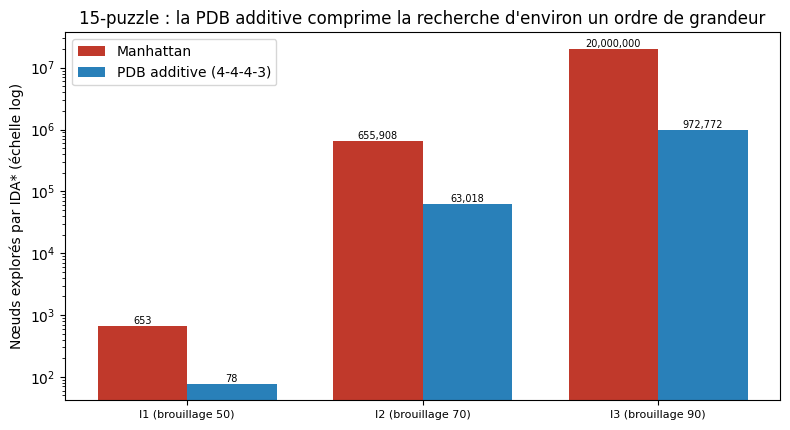

In [10]:
names = [r[0] for r in bench]
man_nodes = [r[4] if r[4] is not None else 20_000_000 for r in bench]
add_nodes = [r[5] if r[5] is not None else 20_000_000 for r in bench]
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.4))
b1 = ax.bar(x - w/2, man_nodes, w, label='Manhattan', color='#c0392b')
b2 = ax.bar(x + w/2, add_nodes, w, label='PDB additive (4-4-4-3)', color='#2980b9')
ax.set_yscale('log'); ax.set_ylabel("Nœuds explorés par IDA* (échelle log)")
ax.set_title("15-puzzle : la PDB additive comprime la recherche d'environ un ordre de grandeur")
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8); ax.legend()
for bars in (b1, b2):
    for r in bars:
        ax.annotate(f'{int(r.get_height()):,}', (r.get_x()+r.get_width()/2, r.get_height()),
                    ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()

## 11. Limites et au-delà

- **Coût de construction.** Plus le groupe est grand, plus la PDB est fine mais
  plus le BFS est coûteux (`P(16,k)` explose). Korf & Felner poussent aux
  partitions **6-6-3** puis **7-8** (avec symétries) pour résoudre les instances à
  ~66 coups — au prix de tables de plusieurs gigaoctets.
- **PDB symétriques.** Le 15-puzzle admet une symétrie (miroir + renversement des
  numéros) qui permet de déduire une seconde PDB gratuitement (Felner et al. 2004).
- **Généralité.** La même technique résout le Rubik's Cube (Korf 1997), la Tour de
  Hanoï, tout puzzle de permutation. C'est l'archétype du compromis
  *mémoire contre qualité d'heuristique*.

## 12. Exercices

> Rappel (convention de la série) : un exercice est un **squelette à compléter**.
> Les stubs s'exécutent sans erreur (`pass` / `return None`) ; à vous de les
> remplir. Ne supprimez pas les `# Indice` / `# Étape N`.

### Exercice 1 — Partition plus fine (6-6-3)

Remplacez la partition 4-4-4-3 par **6-6-3** (Korf & Felner 2002). Combien d'états
par PDB (`P(16,6)×10`, `P(16,3)×13`) ? Mesurez le speedup supplémentaire sur les
instances du banc d'essai. Attention au temps de construction des groupes de 6.

In [11]:
# Exercice 1 — à compléter
GROUPS_663 = [(1,2,3,4,5,6), (7,8,9,10,11,12), (13,14,15)]

def build_additive_for(groups):
    # Indice : réutilisez build_additive_pdb sur chaque groupe. Étape 1 : construisez
    # la liste des tables. Étape 2 : attention, un groupe de 6 -> P(16,6)*10 ~ 57M
    # états (~57 Mo uint8) ; le BFS prend ~1-2 min.
    pass  # TODO etudiant

def h_additive_663(state):
    # Indice : somme des lookups sur GROUPS_663.
    pass  # TODO etudiant

### Exercice 2 — PDB symétrique gratuit (Felner et al. 2004)

Le 15-puzzle possède une symétrie : refléter la grille (miroir vertical) **et**
renverser les numéros (`t -> 16 - t`) laisse le puzzle invariant. Construisez la
transformation `reflect(state)`, vérifiez qu'elle préserve la résolubilité et que
`h_additive(state) == h_additive(reflect(state))`. En déduire une seconde PDB
*gratuite* et combinez-la par `max`.

In [12]:
# Exercice 2 — à compléter
def reflect(state):
    # Indice : miroir vertical de la grille 4x4, puis renversement des numéros
    # t -> 16 - t pour t != 0 (le vide reste le vide).
    # Étape 1 : reshape en 4x4, retournez les colonnes, aplatissez.
    # Étape 2 : mappez chaque tuile t -> 16-t (sauf 0).
    pass  # TODO etudiant

# Indice : vérifiez reflect(reflect(s)) == s et h_additive(s) == h_additive(reflect(s)).

### Exercice 3 — Généralisation au 24-puzzle

Le **24-puzzle** (5×5) est le vrai défi : Manhattan y est désespérément faible et
seules les PDB additives rendent la résolution optimale envisageable. Adaptez ce
notebook (25 cellules, partition 6-6-6-7) et résolvez une instance. Que
constatez-vous sur le rapport construction/qualité ?

In [13]:
# Exercice 3 — à compléter
# Indice : la structure est inchangée ; changent la taille (N=5), le but (1..24,0),
# et la partition. Étape 1 : redéfinissez GOAL24 et neighbors pour N=5.
# Étape 2 : attention à l'explosion de P(25, k) — restez sur des groupes <= 6.
pass  # TODO etudiant

## Conclusion

La **base de données de motifs** illustre un principe central de la recherche
heuristique avancée : **investir du calcul en amont** (précalculer des tables une
fois pour toutes) **pour rendre chaque recherche ultérieure radicalement plus
cheap**. Sur le 15-puzzle, passer de Manhattan à une PDB *additive* comprime
l'arbre exploré par IDA\* d'environ un ordre de grandeur — assez pour résoudre à
l'optimum des instances que Manhattan ne termine pas.

Les trois ingrédients de la technique :

1. **l'abstraction** (garder un motif, jokeriser le reste) ;
2. **le parcours rétrograde** (BFS / 0-1 BFS depuis le but abstrait = distances
   optimales, admissibles parce que le problème abstrait est un relâchement) ;
3. **la combinaison admissible additive** (somme sur des groupes disjoints, en ne
   comptant que les mouvements propres à chaque groupe).

La leçon plus large pour la Partie 3 : quand un problème est trop dur pour une
heuristique « instantanée », la bonne réponse n'est pas d'abandonner l'optimalité
(recherche *anytime* / pondérée — un autre notebook) mais de **précalculer une
heuristique plus fine**, quitte à payer un coût de construction amorti sur des
millions de requêtes.

### Références

- **Korf, R. E. (1985).** *Depth-First Iterative-Deepening: An Optimal Admissible
  Tree Search.* Artificial Intelligence 27(1). — IDA\* et le 15-puzzle comme banc d'essai.
- **Culberson, J. C. & Schaeffer, J. (1996).** *Searching with Pattern Databases.*
  AI\*AI. — invention des PDB.
- **Korf, R. E. & Felner, A. (2002).** *Disjoint Pattern Database Heuristics.*
  Artificial Intelligence 134(1-2). — PDB additives (5-5-5, 6-6-3), la SOTA.
- **Felner, A., Korf, R. E., et al. (2004).** *Additive Pattern Database Heuristics.*
  JAIR 21. — PDB symétriques, raffinements.
- **Korf, R. E. (1997).** *Finding Optimal Solutions to Rubik's Cube Using Pattern
  Databases.* AAAI. — généralisation.
- **Edelkamp, S. & Schrödl, S. (2012).** *Heuristic Search: Theory and Applications.*
  Morgan Kaufmann.

---

← [Search-3 — Recherche informée](../Part1-Foundations/Search-3-Informed.ipynb)
| ↑ [Search (racine)](../README.md) | [Partie 4 — Métaheuristiques →](../Part4-Metaheuristics/README.md)